In [10]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [11]:
import pandas as pd
import numpy as np

In [12]:
results_df = pd.read_csv('output/integration_geoplant_denmark/summary_integration_geoplant.csv')

In [13]:
results_df.fillna(0, inplace=True)

In [14]:
auc_cols_species = ['AUC_PO_only', 'AUC_PO_w_bias',
       'AUC_PO_only_logreg', 'AUC_PA_only', 'AUC_PA_only_logreg',
       'AUC_PO_plus_PA', 'AUC_PO_plus_PA_imputed', 'AUC_PO_plus_PA_ensemble',
       'AUC_Smoothed_PO_plus_PA', 'AUC_Smoothed_with_Prior_PO_plus_PA', 'AUC_PO_plus_PA_bias']

auc_cols_site = [f"{c}_site" for c in auc_cols_species]
auc_cols = auc_cols_species + auc_cols_site


# auc_cols = ['AUC_PA_only', 'AUC_PO_plus_PA', 'AUC_Smoothed_PO_plus_PA', 'AUC_PO_plus_PA_ensemble']
auc_cols_species = [col for col in auc_cols_species if col in results_df.columns]
auc_cols_site = [col for col in auc_cols_site if col in results_df.columns]

In [15]:
results_df.groupby(['region'])[auc_cols_site].mean().mean()


AUC_PO_only_site                           0.5800
AUC_PO_w_bias_site                         0.6393
AUC_PA_only_site                           0.8381
AUC_PO_plus_PA_site                        0.8341
AUC_Smoothed_PO_plus_PA_site               0.8329
AUC_Smoothed_with_Prior_PO_plus_PA_site    0.8349
AUC_PO_plus_PA_bias_site                   0.8491
dtype: float64

In [16]:
results_df.groupby(['region', 'group'])[auc_cols_species].mean().mean()


AUC_PO_only                           0.7746
AUC_PO_w_bias                         0.5000
AUC_PA_only                           0.7609
AUC_PO_plus_PA                        0.7806
AUC_PO_plus_PA_ensemble               0.7739
AUC_Smoothed_PO_plus_PA               0.7833
AUC_Smoothed_with_Prior_PO_plus_PA    0.7803
AUC_PO_plus_PA_bias                   0.7816
dtype: float64

In [17]:
results_df.groupby(['region'])[auc_cols_species].mean().mean()


AUC_PO_only                           0.7746
AUC_PO_w_bias                         0.5000
AUC_PA_only                           0.7609
AUC_PO_plus_PA                        0.7806
AUC_PO_plus_PA_ensemble               0.7739
AUC_Smoothed_PO_plus_PA               0.7833
AUC_Smoothed_with_Prior_PO_plus_PA    0.7803
AUC_PO_plus_PA_bias                   0.7816
dtype: float64

In [18]:

### this works for the long format (better)
results_df.groupby(['region', 'model_type', 'group'])['auc'].mean().groupby(['model_type', 'region']).mean()

KeyError: 'model_type'

In [ ]:
results_df.groupby(['region', 'model_type', 'group'])['auc'].mean().groupby(['model_type', 'region']).mean().groupby(['model_type']).mean()

model_type
PO_Only_Smooth    0.760887
Name: auc, dtype: float64

In [ ]:
avg_region = results_df.groupby(['region', 'model_type'])['auc'].mean()

total_avg = avg_region.groupby(['model_type']).mean()

print(total_avg)

model_type
PO_Only_Smooth    0.758137
Name: auc, dtype: float64


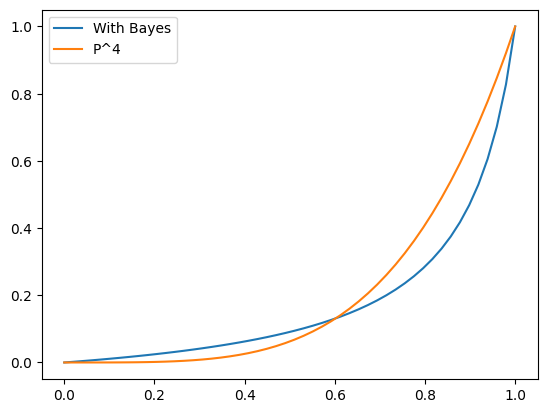

In [2]:
import matplotlib.pyplot as plt
import numpy as np
theta = .1

p = np.linspace(0, 1, 50)
plt.plot(p, p*(theta)/(1 - p + p*(theta)), label=f'With Bayes')
## plot the square
# plt.plot(p, p**2, label='P^2')
# plt.plot(p, p**3, label='P^3')
plt.plot(p, p**4, label='P^4')
# plt.plot(p, p*(1-theta), label='no smoothing')
plt.legend()

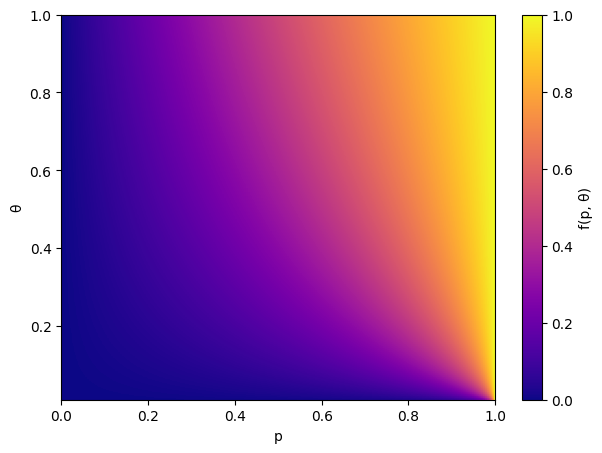

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0, 1, 200)
theta = np.linspace(0.01, 1, 200)

P, T = np.meshgrid(p, theta)
Z = (P * T) / (1 - P + P * T)

plt.figure(figsize=(7,5))
plt.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[p.min(), p.max(), theta.min(), theta.max()],
    cmap="plasma",
)
plt.colorbar(label="f(p, θ)")
plt.xlabel("p")
plt.ylabel("θ")
# plt.title("Bayes-adjusted proba˚bility as a function of p and θ")
plt.show()
